### Lab IV: Linear Models
### Answer all three sets of questions

#### Turn in one python file for the three computation questions and one text file for Q0

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A linear model is linear because of its coeffecients. Each input(our x value/s) is multiplied by a coeffecient and perhaps added another coeffecient into it. This relationship can be plotted even with non-linear relationships which might be able to be transformed into a linear model. Each x is multiplied only by a coeffecient b, there is no changing coeffecient overtime. The main point is that the coeffecients are constants used linearly within the model, not multiplied with each other, or made into exponentials or anything.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.

Since a dummy variable is either 1 or 0. The intercept of the model is the value added if the variable was absent and 0, basically the value of the output when the category that was omitted during encoding is true for a record. The coeffecient is the difference between the value added by the 1 value and the intercept of the model/that omitted category. Thus the output value is the coeffecient*(1 or 0) + the intercept.

3. Can linear regression be used for classification? Explain why, or why not.

Yes, even without a logistical regression algorithm directly(which would count as a different algorithm, even though it is a linear model according to definitions it seems), you could use thresholds to determine classification according to the numeric output you receive.
   
4. If you have a high accuracy on testing but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 

If you have high accuracy on training but low on testing, it suggests that you are overfitting your model which works on training data but fails on testing data. It might be that you can see the residual map fit training data and overcorrect to the noise, and thus fail to generalize and find a more optimal solution.
   
5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?

Two out of the three ways mentioned to incorporate nonlinear relationships between your x and y are to "choose a model that can natively deal with non-linearity" such as a decision tree regressor or "engineer a richer set of features by including expert knowledge which can be directly used by a simple linear model" which means we can use polynomial feature expansion for example to capture squared or cubed relationships.

Additionally a third option mentioned was to "use a “kernel” to have a locally-based decision function instead of a global linear decision function."
   
6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

The intercept is the value if all the input variables were to be set to 0. In that situation the intercept should be equal to y or the numeric output.

The slope coefficient for a variable is the multiplier applied to said value for that variable to calculate its impact on y or the output variable.

The slope coefficient for a dummy variable is the difference between the value added by the 1 value and the intercept of the model/the output value of the omitted category.

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [1059]:
#Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [1060]:
#read in data
df=pd.read_csv("Q1_clean.csv")

In [1061]:
print(df.info())
print(df.columns)
df=df.rename(columns={"Neighbourhood ": "Neighbourhood"}) #There is an extra space
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  object 
 3   Property Type         22153 non-null  object 
 4   Room Type             22153 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 865.5+ KB
None
Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')
Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')


Question 1: Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

Price mean : Neighbourhood
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64
Score mean : Neighbourhood
Bronx            91.654378
Brooklyn         92.363497
Manhattan        91.801496
Queens           91.549057
Staten Island    90.843750
Name: Review Scores Rating, dtype: float64

Manhattan is the most expensive on average


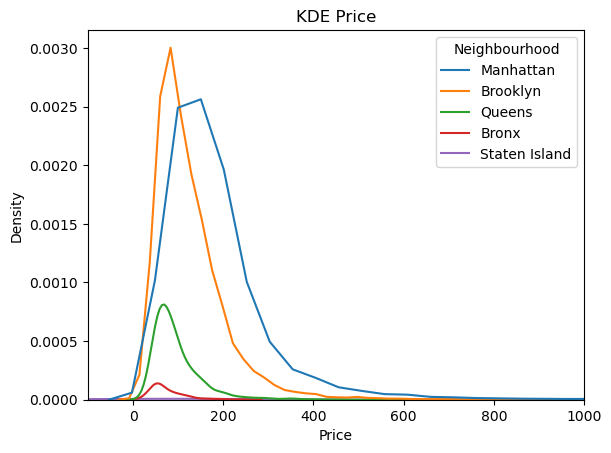

<Figure size 1000x600 with 0 Axes>

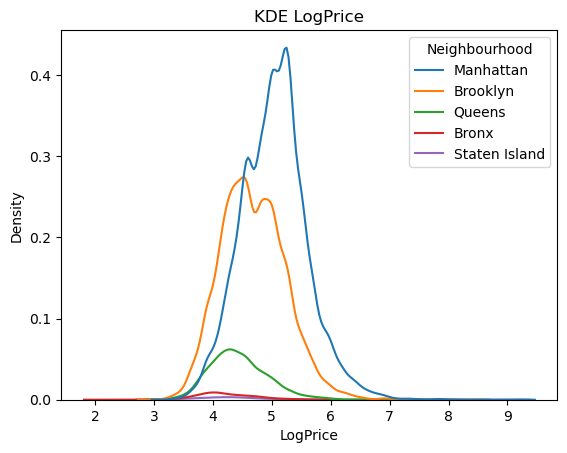

In [1062]:
#Group by neighborhood
print("Price mean : "+str(df.groupby("Neighbourhood")["Price"].mean()))
print("Score mean : "+str(df.groupby("Neighbourhood")["Review Scores Rating"].mean()))

print("\nManhattan is the most expensive on average")

#plot price by individual neighbourhoods
sns.kdeplot(df, x="Price", hue="Neighbourhood")
plt.title("KDE Price")
plt.xlim(-100, 1000) # limit the x values so it doesn't stretch on and become unreadable.s
plt.figure(figsize=(10, 6))
plt.show()

df["LogPrice"]=np.log(df["Price"])  # calc log price

#Make the same graph but for log price instead of price.
sns.kdeplot(df, x="LogPrice", hue="Neighbourhood")
plt.title("KDE LogPrice")
plt.show()

Question 2: Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [1063]:
#categorical=["Neighbourhood","Property Type","Room Type"]
dfq2=df.copy() # Make a copy so the original isn't changed
categorical= ["Neighbourhood"] # Neighbourhood is the only categorical we are using
dfq2[categorical]=dfq2[categorical].astype("category") #encode as category

dfq2 = pd.get_dummies(dfq2, columns=categorical, drop_first=False) # Get dummies from all categories
lin_reg = LinearRegression() #instantiate the model
X= dfq2[["Neighbourhood_Bronx","Neighbourhood_Brooklyn","Neighbourhood_Manhattan","Neighbourhood_Queens","Neighbourhood_Staten Island"]]
y=dfq2["Price"]

lin_reg.fit(X, y) #Train model

print("The pattern is very strange but proportionally is somewhat similar to the graph, however there are negative values which don't really align with what we saw in the graphs earlier")
print("Intercept: "+str(lin_reg.intercept_))
print("The coefficients are: "+ str(lin_reg.coef_))


The pattern is very strange but proportionally is somewhat similar to the graph, however there are negative values which don't really align with what we saw in the graphs earlier
Intercept: 125.94241234635741
The coefficients are: [-50.66591465   1.804966    57.72187398 -29.08517964  20.22425432]


Question 3: Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

In [1064]:
dfq3=df.copy()
dfq3 = pd.get_dummies(dfq3, columns=categorical, drop_first=True) # Get dummies

lin_regq3 = LinearRegression() # New instantiated model

#Make input value and output values to train upon.
X= dfq3[["Neighbourhood_Brooklyn","Neighbourhood_Manhattan","Neighbourhood_Queens","Neighbourhood_Staten Island"]]
y= dfq3["Price"]

lin_regq3.fit(X, y) #Train
print("We handle the dummies differently by dropping first")
print("The intercept is the value when Neighbourhood_Bronx is true")
print("You could get the coefficients from part 2 by adding part 2's intercept to part 2's coefficient")
print("Intercept: "+str(lin_regq3.intercept_))
print("The coefficients are: "+ str(lin_regq3.coef_))

We handle the dummies differently by dropping first
The intercept is the value when Neighbourhood_Bronx is true
You could get the coefficients from part 2 by adding part 2's intercept to part 2's coefficient
Intercept: 75.27649769585406
The coefficients are: [ 52.47088065 108.38778863  21.58073501  70.89016897]


Question 4: Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [ ]:
#categorical=["Neighbourhood","Property Type","Room Type"]
dfq4=df.copy()

dfq4 = pd.get_dummies(dfq4, columns=categorical, drop_first=True)# Get dummies once more

# Splits into two sets, one to train, one to test accuracy and other metrics
train_set, test_set = train_test_split(dfq4, test_size=0.2, random_state=44)

lin_regq4 = LinearRegression()

#Make our two data sets from train only
X= train_set[["Neighbourhood_Brooklyn","Neighbourhood_Manhattan","Neighbourhood_Queens","Neighbourhood_Staten Island","Review Scores Rating"]]
y= train_set["Price"]

#Train model on said train data
lin_regq4.fit(X, y)

#print intercepts and coefficients
print("Intercept: "+str(lin_regq4.intercept_))
print("The coefficients are: "+ str(lin_regq4.coef_))

#Make our predictions(using test data now), get r2 and rmse for later as well.
pred=lin_regq4.predict(test_set[["Neighbourhood_Brooklyn","Neighbourhood_Manhattan","Neighbourhood_Queens","Neighbourhood_Staten Island","Review Scores Rating"]])
r2 = r2_score(test_set["Price"], pred) # natively defined in sklearn.
rmse = np.sqrt(mean_squared_error(test_set["Price"], pred)) # The root of mean squared error is rmse, so I can just use numpy for it and the sklearn function

#Print answers, r2, and rmse
print(f"R^2 = {r2} and RMSE = {rmse}")
print("What is the coefficient on Review Scores Rating? 1.10383075")
print("What is the most expensive kind of property you can rent? Manhattan neighbourhoods(I presume this question was meant for the next part of this assignment)")



Intercept: -25.984028936424068
The coefficients are: [ 51.79281396 107.90696836  22.68860333  82.08931998   1.10383075]
R^2 = 0.05970809333729332 and RMSE = 136.00726500208185
What is the coefficient on Review Scores Rating? 1.10383075
What is the most expensive kind of property you can rent? Manhattan neighbourhoods(I presume this question was meant for the next part of this assignment)


Question 5: Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [1066]:
categorical=["Neighbourhood","Property Type"] # added property type this time.

dfq5=df.copy()

#Get dummies again, but now for more than just the Neighbourhood categories.
dfq5 = pd.get_dummies(dfq5, columns=categorical, drop_first=True)

train_set, test_set = train_test_split(dfq5, test_size=0.2, random_state=44)

lin_regq5 = LinearRegression() # Instantiate model once more

# Every possible combination of neighbourhood,
X= train_set[["Neighbourhood_Brooklyn","Neighbourhood_Manhattan","Neighbourhood_Queens","Neighbourhood_Staten Island","Review Scores Rating",'Property Type_Bed & Breakfast', 'Property Type_Boat',
       'Property Type_Bungalow', 'Property Type_Cabin',
       'Property Type_Camper/RV', 'Property Type_Castle',
       'Property Type_Chalet', 'Property Type_Condominium',
       'Property Type_Dorm', 'Property Type_House', 'Property Type_Hut',
       'Property Type_Lighthouse', 'Property Type_Loft', 'Property Type_Other',
       'Property Type_Townhouse', 'Property Type_Treehouse',
       'Property Type_Villa']] # THAT IS WAY TOO MANY HA

y= train_set["Price"] # get output to train on
lin_regq5.fit(X, y) # Train data

print("Intercept: "+str(lin_regq5.intercept_))
print("The coefficients are: "+ str(lin_regq5.coef_))


# Do prediction, r2, and rmse steps as before, this time with the many property type values as well.
pred=lin_regq5.predict(test_set[["Neighbourhood_Brooklyn","Neighbourhood_Manhattan","Neighbourhood_Queens","Neighbourhood_Staten Island","Review Scores Rating",'Property Type_Bed & Breakfast', 'Property Type_Boat',
       'Property Type_Bungalow', 'Property Type_Cabin',
       'Property Type_Camper/RV', 'Property Type_Castle',
       'Property Type_Chalet', 'Property Type_Condominium',
       'Property Type_Dorm', 'Property Type_House', 'Property Type_Hut',
       'Property Type_Lighthouse', 'Property Type_Loft', 'Property Type_Other',
       'Property Type_Townhouse', 'Property Type_Treehouse',
       'Property Type_Villa']])

r2 = r2_score(test_set["Price"], pred)
rmse = np.sqrt(mean_squared_error(test_set["Price"], pred)) # The root of mean squared error is rmse

print(f"R^2 = {r2} and RMSE = {rmse}")
print("What is the coefficient on Review Scores Rating? 1.09384153")
print("What is the most expensive kind of property you can rent? Property Type_Condominium")

Intercept: -37.62990071959621
The coefficients are: [  57.6460764   118.83125839   27.31275079   75.32346361    1.09384153
  -35.69798152   74.17566451   26.04296642    8.27903482  -10.05502886
  -40.58551115    0.           93.37517563  -50.04728011   31.35201227
 -134.02246195  -90.40032916   67.91880853   41.46757089   61.4139664
   10.23770075   33.35986645]
R^2 = 0.06890336000583486 and RMSE = 135.3406126492575
What is the coefficient on Review Scores Rating? 1.09384153
What is the most expensive kind of property you can rent? Property Type_Condominium


Question 6: What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

The coefficient for Review Scores Rating did change slightly, but if it hypothetically changed more this would represent the shift as the new columns were added. The model was using a lot less columns before to explain how to reach its predicted price, and as these new values were added, Review Scores Rating would either hypothetically become less important, its coefficient reducing towards 0, as other variables explained the variation of the model better, or maybe more important and the coefficient value increases. This is because linear regression takes all variables into account and their coefficients represent how they operate as a part of the greater whole in order to calculate the target variable, they don't operate separately.

Question 7 (Optional): We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

Question 1: Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [ ]:
# Read in data
cars = pd.read_csv("cars_hw.csv")

cars=cars.drop(columns=["Unnamed: 0"]) # Removing redundant column which was unhelpful for my use

print(cars)
print(cars.columns)

#Price definitely needed a log transformation

#sns.histplot(cars["Price"], kde=True)
#plt.show()
#sns.histplot(np.log(cars["Price"]), kde=True)
#plt.show()

cars["LogPrice"]=np.log(cars["Price"])

print(cars.info())
print(cars.describe())

              Make  Make_Year   Color  Body_Type  Mileage_Run No_of_Owners  \
0       Volkswagen       2017  silver      sedan        44611          1st   
1          Hyundai       2016     red  crossover        20305          1st   
2            Honda       2019   white        suv        29540          2nd   
3          Renault       2017  bronze  hatchback        35680          1st   
4          Hyundai       2017  orange  hatchback        25126          1st   
..             ...        ...     ...        ...          ...          ...   
971        Hyundai       2018   white      sedan        23869          1st   
972        Hyundai       2019   white      sedan        14831          1st   
973        Hyundai       2014  silver      sedan        52846          1st   
974           Ford       2020   white  crossover        28335          2nd   
975  Maruti Suzuki       2018  silver  hatchback        41176          1st   

     Seating_Capacity Fuel_Type Transmission Transmission_Type 

Question 2: Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

In [ ]:
Make=cars.groupby("Make")
print("Price described : "+str(Make["Price"].describe()))

Price described :                count          mean           std        min        25%  \
Make                                                                     
Chevrolet        6.0  4.535000e+05  2.466064e+05   267000.0   288500.0   
Datsun           3.0  2.896667e+05  1.050397e+04   279000.0   284500.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  2.160199e+05   237000.0   411000.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Renault         68.0

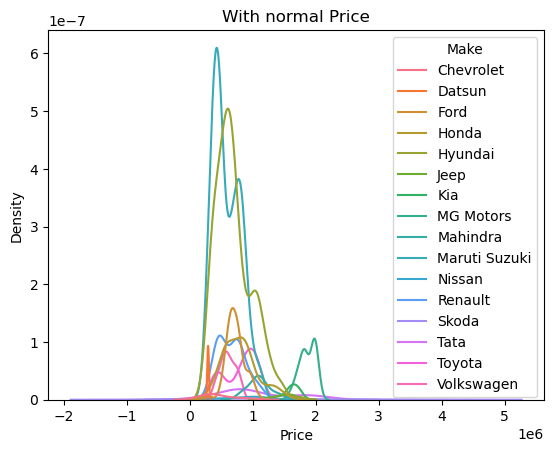

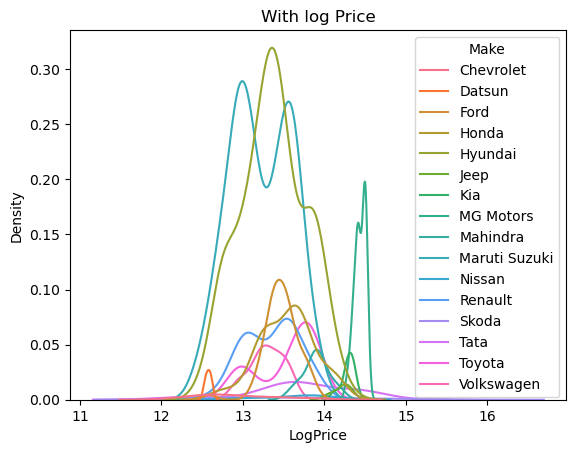

In [1083]:
#KDE plots with price and log price to see the difference
sns.kdeplot(cars, x="Price", hue="Make")
plt.title("With normal Price")
plt.show()
sns.kdeplot(cars, x="LogPrice", hue="Make")
plt.title("With log Price")
plt.show()

MG Motors, Kia, and Jeep appear to be the most expensive car brands each around or over a million dollars and 400 thousand for the average of their car models.

In general, however, the average prices seem to near the 500,000 mark. Especially for Hyundai and Maruti Suzuki, whom have the greatest number in general of cars. There is a large collection however that is slightly under this number and another that is slightly above.

Question 3: Split the data into an 80% training set and a 20% testing set.

In [1070]:
# Quickly set the right columns to be categorical before splitting so this is the case in test and train data.
categorical= ['Make', 'Body_Type', 'Fuel_Type', 'Transmission', "Transmission_Type"]
cars[categorical]=cars[categorical].astype("category") 

In [1071]:
train_cars, test_cars = train_test_split(cars, test_size=0.2, random_state=44)

Question 4: Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

In [ ]:
# Get dummies for categorical data, which since our data set is already split we do this transformation to both train and test

newcarstrain = pd.get_dummies(train_cars, columns=categorical, drop_first=True)
newcarstest = pd.get_dummies(test_cars, columns=categorical, drop_first=True)

# Numeric data model

lin_alg = LinearRegression() # Instantiate model

lin_alg.fit(newcarstrain[['Make_Year', 'Mileage_Run','Seating_Capacity']],newcarstrain['LogPrice']) # Use the numeric columns to train

predtrain=lin_alg.predict(newcarstrain[['Make_Year', 'Mileage_Run','Seating_Capacity']]) # predict using train data

r2 = r2_score(newcarstrain["LogPrice"], predtrain) # natively defined in sklearn.
rmse = np.sqrt(mean_squared_error(newcarstrain["LogPrice"], predtrain)) # The root of mean squared error is rmse, so I can just use numpy for it and the sklearn function

print(f"R^2 = {r2} and RMSE = {rmse}")

pred=lin_alg.predict(newcarstest[['Make_Year', 'Mileage_Run','Seating_Capacity']]) # predict using test data

r2 = r2_score(newcarstest["LogPrice"], pred) # natively defined in sklearn.
rmse = np.sqrt(mean_squared_error(newcarstest["LogPrice"], pred)) # The root of mean squared error is rmse, so I can just use numpy for it and the sklearn function

print(f"R^2 = {r2} and RMSE = {rmse}")

# Second model with categorical data

lin_alg = LinearRegression() # Instantiate model

# Train categorical data into model

lin_alg.fit(newcarstrain[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']],newcarstrain['LogPrice'])

# Predict train data

predtrain=lin_alg.predict(newcarstrain[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']])

#Score our training data

r2 = r2_score(newcarstrain["LogPrice"], predtrain) # natively defined in sklearn.
rmse = np.sqrt(mean_squared_error(newcarstrain["LogPrice"], predtrain)) # The root of mean squared error is rmse, so I can just use numpy for it and the sklearn function

print(f"R^2 = {r2} and RMSE = {rmse}")

# Predict test data

pred=lin_alg.predict(newcarstest[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']])

# r2 and rmse for test data

r2 = r2_score(newcarstest["LogPrice"], pred) # natively defined in sklearn.
rmse = np.sqrt(mean_squared_error(newcarstest["LogPrice"], pred)) # The root of mean squared error is rmse, so I can just use numpy for it and the sklearn function

# print output and conclusion

print(f"R^2 = {r2} and RMSE = {rmse}")

print("The second model is better it seems, but both are rather accurate")

# Combination of the other models

lin_alg = LinearRegression() # Numeric data and categorical

# I trained model with train data using the numeric features AND categorical data now

lin_alg.fit(newcarstrain[['Make_Year', 'Mileage_Run','Seating_Capacity','Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']],newcarstrain['LogPrice'])

#predict using the train data

predtrain=lin_alg.predict(newcarstrain[['Make_Year', 'Mileage_Run','Seating_Capacity','Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']])

#score our training data

r2 = r2_score(newcarstrain["LogPrice"], predtrain) # natively defined in sklearn.
rmse = np.sqrt(mean_squared_error(newcarstrain["LogPrice"], predtrain)) # The root of mean squared error is rmse, so I can just use numpy for it and the sklearn function

print(f"R^2 = {r2} and RMSE = {rmse}")

#predict using the test data

pred=lin_alg.predict(newcarstest[['Make_Year', 'Mileage_Run','Seating_Capacity','Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']])

#score our testing data

r2 = r2_score(newcarstest["LogPrice"], pred) # natively defined in sklearn.
rmse = np.sqrt(mean_squared_error(newcarstest["LogPrice"], pred)) # The root of mean squared error is rmse, so I can just use numpy for it and the sklearn function

print(f"R^2 = {r2} and RMSE = {rmse}")

print("The joint model performs better and by around 0.1 or like 0.15 on RMSE, and the R^2 improved greatly by around 0.2 from the second model")


R^2 = 0.41094228624451723 and RMSE = 0.3418914746916204
R^2 = 0.408180006514571 and RMSE = 0.3598870873275196
R^2 = 0.6582591534583033 and RMSE = 0.2604100813374132
R^2 = 0.6153067409986662 and RMSE = 0.29015411637017996
The second model is better it seems, but both are rather accurate
R^2 = 0.8307156874428656 and RMSE = 0.18328110935727984
R^2 = 0.797029224372165 and RMSE = 0.2107600067299837
The joint model performs better and by around 0.1 or like 0.15 on RMSE, and the R^2 improved greatly by around 0.2 from the second model


Question 5: Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [ ]:
# Poly = 2

pf = PolynomialFeatures(2)

# Fit and transform depending on train or test data with the numeric values

X_train_poly = pf.fit_transform(newcarstrain[['Make_Year', 'Mileage_Run','Seating_Capacity']])
X_test_poly  = pf.transform(newcarstest[['Make_Year', 'Mileage_Run','Seating_Capacity']])

# Combine both lists to have numeric and categorical data now

X_train = np.hstack([X_train_poly, newcarstrain[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']
].values])

X_test  = np.hstack([X_test_poly, newcarstest[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']
].values])

# Train

lin_alg.fit(X_train, newcarstrain['LogPrice'])

# Make predictions

pred_test = lin_alg.predict(X_test)

#Grab list of true values
y_true = newcarstest['LogPrice'].values

#calculate r2 and rmse

r2 = r2_score(newcarstest['LogPrice'], pred)
rmse = np.sqrt(mean_squared_error(newcarstest['LogPrice'], pred))

print(f"R^2 = {r2} and RMSE = {rmse}")

# poly = 3

pf = PolynomialFeatures(3)

X_train_poly = pf.fit_transform(newcarstrain[['Make_Year', 'Mileage_Run','Seating_Capacity']])
X_test_poly  = pf.transform(newcarstest[['Make_Year', 'Mileage_Run','Seating_Capacity']])

X_train = np.hstack([X_train_poly, newcarstrain[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']
].values])

X_test  = np.hstack([X_test_poly, newcarstest[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']
].values])

lin_alg.fit(X_train, newcarstrain['LogPrice'])

pred = lin_alg.predict(X_train)

r2 = r2_score(newcarstrain['LogPrice'], pred)
rmse = np.sqrt(mean_squared_error(newcarstrain['LogPrice'], pred))

print("poly = 3")
print(f"R^2 = {r2} and RMSE = {rmse}")

pred = lin_alg.predict(X_test)

r2 = r2_score(newcarstest['LogPrice'], pred)
rmse = np.sqrt(mean_squared_error(newcarstest['LogPrice'], pred))

print(f"R^2 = {r2} and RMSE = {rmse}")

# poly = 8

pf = PolynomialFeatures(8)

X_train_poly = pf.fit_transform(newcarstrain[['Make_Year', 'Mileage_Run','Seating_Capacity']])
X_test_poly  = pf.transform(newcarstest[['Make_Year', 'Mileage_Run','Seating_Capacity']])

X_train = np.hstack([X_train_poly, newcarstrain[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']
].values])

X_test  = np.hstack([X_test_poly, newcarstest[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']
].values])

lin_alg.fit(X_train, newcarstrain['LogPrice'])

pred = lin_alg.predict(X_train)

r2 = r2_score(newcarstrain['LogPrice'], pred)
rmse = np.sqrt(mean_squared_error(newcarstrain['LogPrice'], pred))

print("poly = 8")
print(f"R^2 = {r2} and RMSE = {rmse}")

pred = lin_alg.predict(X_test)

r2 = r2_score(newcarstest['LogPrice'], pred)
rmse = np.sqrt(mean_squared_error(newcarstest['LogPrice'], pred))

print(f"R^2 = {r2} and RMSE = {rmse}")

poly = 2
R^2 = 0.8422657563306445 and RMSE = 0.17691813053239702
R^2 = 0.7950942304810189 and RMSE = 0.21176224943610797
poly = 3
R^2 = 0.4350895430491296 and RMSE = 0.33481056573684886
R^2 = 0.44512693035014206 and RMSE = 0.34847230792197237
poly = 8
R^2 = 0.19209816195627394 and RMSE = 0.4003950002999935
R^2 = -0.42644697145384614 and RMSE = 0.5587264917909128


#### As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? 

As the degree increased, R^2 decreased and RMSE increased.

#### At what point does $R^2$ go negative on the test set? 

Poly = 8 was when R^2 went negative on the test set for me.

#### For your best model with expanded features, what is the $R^2$ and `RMSE`? 

R^2 = 0.7950942304810189 and RMSE = 0.21176224943610797 on the test set.

#### How does it compare to your best model from part 4?

POLY: R^2 = 0.7950942304810189 and RMSE = 0.21176224943610797
PART 4: R^2 = 0.797029224372165 and RMSE = 0.2107600067299837

Both were very similar to each other

  Question 6: For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

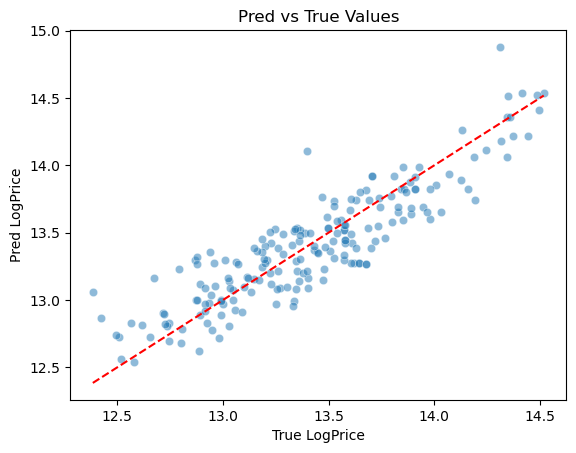

In [ ]:
# Poly = 2

pf = PolynomialFeatures(2)

# Fit and transform depending on train or test data with the numeric values

X_train_poly = pf.fit_transform(newcarstrain[['Make_Year', 'Mileage_Run','Seating_Capacity']])
X_test_poly  = pf.transform(newcarstest[['Make_Year', 'Mileage_Run','Seating_Capacity']])

# Combine both lists to have numeric and categorical data now

X_train = np.hstack([X_train_poly, newcarstrain[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']
].values])

X_test  = np.hstack([X_test_poly, newcarstest[['Make_Datsun', 'Make_Ford', 'Make_Honda',
       'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Body_Type_hatchback', 'Body_Type_muv', 'Body_Type_sedan',
       'Body_Type_suv', 'Fuel_Type_petrol', 'Fuel_Type_petrol+cng',
       'Transmission_5-Speed', 'Transmission_6-Speed', 'Transmission_7-Speed',
       'Transmission_CVT', 'Transmission_Type_Manual']
].values])

# Train

lin_alg.fit(X_train, newcarstrain['LogPrice'])

# Make predictions

pred_test = lin_alg.predict(X_test)
y_true = newcarstest['LogPrice'].values

# Plotting pred and true 
sns.scatterplot(x=y_true, y=pred_test, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--')  # diagonal line from the minimum of the x and y and to maximum to x and y.
plt.xlabel("True LogPrice")
plt.ylabel("Pred LogPrice")
plt.title("Pred vs True Values")
plt.show()

Do the predicted values and true values roughly line up along the diagonal, or not?

Yes, it is roughly diagonal.

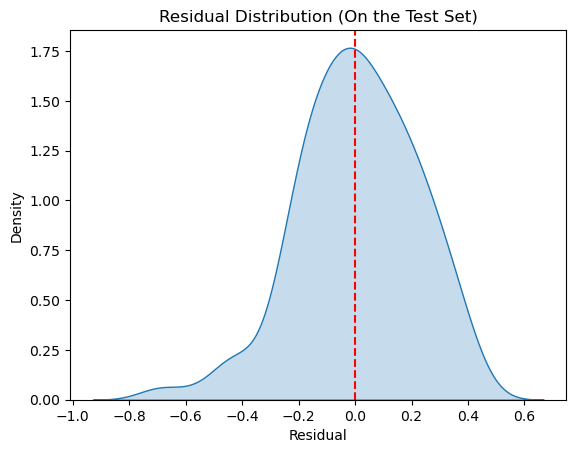

In [1075]:
residuals = y_true - pred_test # Computes the residuals

sns.kdeplot(residuals, fill=True) # KDE PLOT with the residuals
plt.axvline(0, color='red', linestyle='--') # horizontal line at 0
plt.xlabel("Residual")
plt.title("Residual Distribution (On the Test Set)")
plt.show()

Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

Yes the model is roughly bell-shaped around zero. Sometimes it has larger negative residuals, but otherwise it seems to be rather consistently good at predicting as within 0.3 residuals, it seems to capture most residuals

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

Question 1: Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

In [1076]:
fish=pd.read_csv("fish.csv")

Question 2: Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.

In [ ]:
# Look at the data
print(fish.columns)
print(fish.info())
print(fish.describe())

# One hot encode the species for the model
categorical=["Species"]
fish[categorical]=fish[categorical].astype("category")

# Grab our one hot encodings for the categorical variable, species
fishD = pd.get_dummies(fish, columns=categorical, drop_first=True)
print(fishD.columns)

#calculate a length average, which will turn out to not be very helpful
fishD["Length_avg"] = (fishD["Length1"] + fishD["Length2"] + fishD["Length3"]) / 3 

X = fishD[['Length1', 'Length2', 'Length3', 'Height', "Width",
       'Species_Parkki', 'Species_Perch', 'Species_Pike', 'Species_Roach',
       'Species_Smelt', 'Species_Whitefish']] # My possible inputs including every fish species

y = fishD["Weight"] # My target Variable

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB
None
            Weight     Length1     Length2     Length3      Height       Width
count   159.000000  159.000000  159.000000  159.000000  159.000000  159.000000
mean    398.326415   26.247170   28.415723   31.227044    8.970994    4.417486
std     357.978317    9.996441   10.716328   11.610246    4.286208    1.685804
min       0.000000    7.500000    8.400000    8.800000    1.728400    1

Question 3: Split the sample into an ~80% training set and a ~20% test set.

In [1078]:
train_fish, test_fish = train_test_split(fishD, test_size=0.2, random_state=44)

Question 4: Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.

In [1079]:
# Make model

lin_alg = LinearRegression()

# Feature vars available, using all info(except length avg)

Xfish = train_fish[['Length1', 'Length2', 'Length3', 'Height', "Width",
       'Species_Parkki', 'Species_Perch', 'Species_Pike', 'Species_Roach',
       'Species_Smelt', 'Species_Whitefish']]

# Target Var

yfish = train_fish["Weight"]

# Train model

lin_alg.fit(Xfish, yfish)

# Predict on test data

fishpred = lin_alg.predict(test_fish[['Length1', 'Length2', 'Length3', 'Height', "Width",
       'Species_Parkki', 'Species_Perch', 'Species_Pike', 'Species_Roach',
       'Species_Smelt', 'Species_Whitefish']])

# Calculate RMSE

rmse = np.sqrt(mean_squared_error(test_fish["Weight"], fishpred))

print(rmse)

88.46647177255258


In [1080]:
# Make model

lin_alg = LinearRegression()

# Feature vars available, using no species info

Xfish = train_fish[['Length1', 'Length2', 'Length3', 'Height', "Width"]]

# Target Var

yfish = train_fish["Weight"]

# Train model

lin_alg.fit(Xfish, yfish)

# Predict on test data

fishpred = lin_alg.predict(test_fish[['Length1', 'Length2', 'Length3', 'Height', "Width"]])

# Calculate RMSE

rmse = np.sqrt(mean_squared_error(test_fish["Weight"], fishpred))

print(rmse)

135.11719350749846


In [1081]:
# Make model
lin_alg = LinearRegression()

# Feature vars available

Xfish = train_fish[['Length_avg', 'Height', "Width",
       'Species_Parkki', 'Species_Perch', 'Species_Pike', 'Species_Roach',
       'Species_Smelt', 'Species_Whitefish']]

# Target Var

yfish = train_fish["Weight"]

# Train model

lin_alg.fit(Xfish, yfish)

# Predict on test data

fishpred = lin_alg.predict(test_fish[['Length_avg', 'Height', "Width",
       'Species_Parkki', 'Species_Perch', 'Species_Pike', 'Species_Roach',
       'Species_Smelt', 'Species_Whitefish']])

# Calculate RMSE

rmse = np.sqrt(mean_squared_error(test_fish["Weight"], fishpred))

print(rmse)

92.3241478207363


Question 5: Which model performed the best, and why?

The model that performed best was the dataset that already contained everything, and this is probably because length1, length2, and length3 are related to quartile values, and therefore offer more information when all are there together. The species also has a big effect that could've been expected.

So the first model made was best.

Question 6: What did you learn?

I learned that you can predict the weight of a fish, somewhat inaccurately, even with all this information. I was surprised that there wasn't an easy way to reduce the RMSE even with some feature differences between the models, which was much higher than the model for Question 2.

### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it below:

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:


In [1082]:
#from sklearn import linear_model
#from sklearn.model_selection import train_test_split
    
#X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
#regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 
#1 column after dummy encoding

#regr.fit(X_train, Y_train)
#predicted = regr.predict(X_test)

### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 
